5.2

In [1]:
#fashion_mnist: 토치비전에 내장된 예제 데이터
#라이브러리 호출
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

In [2]:
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
'''
#일반적으로 GPU를 사용할 때 이용하는 코드
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model=Net()
model.to(device)

#다수의 GPU를 사용한다면
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=Net()
if torch.cuda.device_count()>1:
    model=nn.DataParallel(net)
model.to(device)
'''

'\n#일반적으로 GPU를 사용할 때 이용하는 코드\ndevice=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")\nmodel=Net()\nmodel.to(device)\n\n#다수의 GPU를 사용한다면\ndevice=torch.device("cuda" if torch.cuda.is_available() else "cpu")\nmodel=Net()\nif torch.cuda.device_count()>1:\n    model=nn.DataParallel(net)\nmodel.to(device)\n'

In [4]:
#데이터셋 내려받기
train_dataset=torchvision.datasets.FashionMNIST('./content', download=True,
                                                transform=transforms.Compose([transforms.ToTensor()]))
test_dataset=torchvision.datasets.FashionMNIST('./content', download=True,
                                                train=False, transform=transforms.Compose([transforms.ToTensor()]))

In [5]:
#데이터를 데이터로더에 전달
train_loader=torch.utils.data.DataLoader(train_dataset,
                                         batch_size=100)
test_loader=torch.utils.data.DataLoader(test_dataset,
                                        batch_size=100)

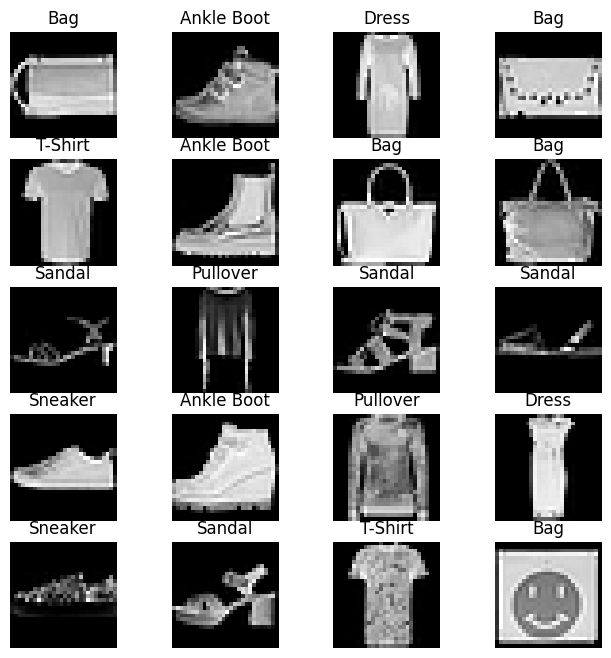

In [6]:
#분류에 사용된 클래스 정의
labels_map={0:'T-Shirt', 1:'Trouser', 2:'Pullover', 3:'Dress', 4:'Coat',
            5:'Sandal', 6:'Shirt', 7:'Sneaker', 8:'Bag', 9:'Ankle Boot'}

fig=plt.figure(figsize=(8,8))
columns=4
rows=5
for i in range(1, columns*rows+1):
    img_xy=np.random.randint(len(train_dataset)) #이산형 분포를 갖는 데이터에서 무작위 표본을 추출할 때 사용
    img=train_dataset[img_xy][0][0,:,:]
    fig.add_subplot(rows, columns, i)
    plt.title(labels_map[train_dataset[img_xy][1]])
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show()

In [7]:
#random.rand와 random.randn 예시
import numpy as np
np.random.randint(10)

9

In [8]:
np.random.randint(1,10)

5

In [9]:
np.random.rand(8)

array([0.83161513, 0.75137998, 0.96769732, 0.34363917, 0.37026292,
       0.82372376, 0.65388681, 0.49625835])

In [10]:
np.random.rand(4,2)

array([[0.39627832, 0.19421528],
       [0.46463923, 0.17182208],
       [0.87036047, 0.40941711],
       [0.41118288, 0.84550724]])

In [11]:
np.random.randn(8)

array([ 0.28813786, -0.78710632,  1.15682711,  0.0501352 ,  1.21607592,
       -0.08571839,  0.47327206, -1.71735935])

In [12]:
np.random.randn(4,2)

array([[ 1.10070606,  1.86822798],
       [ 0.52656477, -1.73350091],
       [-0.27571608, -1.0766189 ],
       [-2.07267345, -0.07839615]])

In [13]:
#배열 예시
import numpy as np
examp=np.arange(0,100,3)
examp.resize(6,4)
examp

array([[ 0,  3,  6,  9],
       [12, 15, 18, 21],
       [24, 27, 30, 33],
       [36, 39, 42, 45],
       [48, 51, 54, 57],
       [60, 63, 66, 69]])

In [14]:
examp[3]

array([36, 39, 42, 45])

In [15]:
examp[3,3]

np.int64(45)

In [16]:
examp[3][3]

np.int64(45)

In [17]:
examp=np.arange(0,500,3)
examp.resize(3,5,5)
examp

array([[[  0,   3,   6,   9,  12],
        [ 15,  18,  21,  24,  27],
        [ 30,  33,  36,  39,  42],
        [ 45,  48,  51,  54,  57],
        [ 60,  63,  66,  69,  72]],

       [[ 75,  78,  81,  84,  87],
        [ 90,  93,  96,  99, 102],
        [105, 108, 111, 114, 117],
        [120, 123, 126, 129, 132],
        [135, 138, 141, 144, 147]],

       [[150, 153, 156, 159, 162],
        [165, 168, 171, 174, 177],
        [180, 183, 186, 189, 192],
        [195, 198, 201, 204, 207],
        [210, 213, 216, 219, 222]]])

In [18]:
examp[2][0][3]

np.int64(159)

In [19]:
#심층 신경망 모델 생성
class FashionDNN(nn.Module):
    def __init__(self):
        super(FashionDNN, self).__init__()
        self.fc1=nn.Linear(in_features=784, out_features=256)
        self.drop=nn.Dropout(0.25)
        self.fc2=nn.Linear(in_features=256, out_features=128)
        self.fc3=nn.Linear(in_features=128, out_features=10)

    def forward(self, input_data):
        out=input_data.view(-1, 784)
        out=F.relu(self.fc1(out))
        out=self.drop(out)
        out=F.relu(self.fc2(out))
        out=self.fc3(out)
        return out

클래스와 함수의 차이

In [20]:
def add(num1, num2):
    result=num1+num2
    return result

print(add(1,2))
print(add(2,3))

3
5


In [21]:
class calc:
    def __init__(self):
        self.result=0

    def add(self, num1, num2):
        self.result=num1+num2
        return self.result

obj1=calc()
obj2=calc()

print(obj1.add(1,2))
print(obj1.add(2,3))
print('----------------')
print(obj2.add(2,2))
print(obj2.add(2,3))

3
5
----------------
4
5


nn vs nn.functional

In [22]:
import torch
import torch.nn as nn

inputs=torch.randn(64,3,244,244)
conv=nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
outputs=conv(inputs)
layer=nn.Conv2d(1,1,3)

In [23]:
import torch.nn.functional as F

inputs=torch.randn(64,3,244,244)
weight=torch.randn(64,3,3,3)
bias=torch.randn(64)
outputs=F.conv2d(inputs, weight, bias, padding=1)

심층 신경망에서 필요한 파라미터 정의

In [24]:
learning_rate=0.001
model=FashionDNN()
model.to(device)

criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(), lr=learning_rate)
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


심층 신경망을 이용한 모델 학습

In [25]:
num_epochs=5
count=0
loss_list=[]
iteration_list=[]
accuracy_list=[]

predictions_list=[]
labels_list=[]

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels=images.to(device), labels.to(device)

        train=Variable(images.view(100,1,28,28))
        labels=Variable(labels)

        outputs=model(train)
        loss=criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count+=1

        if not (count % 50):
            total=0
            correct=0
            for images, labels in test_loader:
                images, labels=images.to(device), labels.to(device)
                labels_list.append(labels)
                test=Variable(images.view(100,1,28,28))
                outputs=model(test)
                predictions=torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct+= (predictions==labels).sum()
                total+=len(labels)

            accuracy=correct*100/total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print('Iteration: {}, Loss: {}, Accuracy: {}%'.format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.5808965563774109, Accuracy: 83.80999755859375%
Iteration: 1000, Loss: 0.488129198551178, Accuracy: 84.58999633789062%
Iteration: 1500, Loss: 0.37563055753707886, Accuracy: 84.66000366210938%
Iteration: 2000, Loss: 0.4466017186641693, Accuracy: 85.5199966430664%
Iteration: 2500, Loss: 0.23936904966831207, Accuracy: 86.22000122070312%
Iteration: 3000, Loss: 0.2952274680137634, Accuracy: 86.27999877929688%


In [28]:
'''
classification accuracy=correct predictions / total predictions
classification accuracy=correct predictions / total predictions *100
error rate= (1- (correct predictions / total predictions))*100
'''

'\nclassification accuracy=correct predictions / total predictions\nclassification accuracy=correct predictions / total predictions *100\nerror rate= (1- (correct predictions / total predictions))*100\n'

합성곱 네트워크 생성

In [27]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.layer1=nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2=nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc1=nn.Linear(in_features=64*6*6, out_features=600)
        self.drop=nn.Dropout2d(0.25)
        self.fc2=nn.Linear(in_features=600, out_features=120)
        self.fc3=nn.Linear(in_features=120, out_features=10)

    def forward(self, x):
        out=self.layer1(x)
        out=self.layer2(out)
        out=out.view(out.size(0),-1)
        out=self.fc1(out)
        out=self.drop(out)
        out=self.fc2(out)
        out=self.fc3(out)
        return out

합성곱 네트워크를 위한 파라미터 정의

In [29]:
learning_rate=0.001
model=FashionCNN()
model.to(device)

criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(), lr=learning_rate)
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


모델 학습 및 성능 평가

In [30]:
num_epochs=5
count=0
loss_list=[]
iteration_list=[]
accuracy_list=[]

predictions_list=[]
labels_list=[]

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels=images.to(device), labels.to(device)

        train=Variable(images.view(100,1,28,28))
        labels=Variable(labels)

        outputs=model(train)
        loss=criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count+=1

        if not (count % 50):
            total=0
            correct=0
            for images, labels in test_loader:
                images, labels=images.to(device), labels.to(device)
                labels_list.append(labels)
                test=Variable(images.view(100,1,28,28))
                outputs=model(test)
                predictions=torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct+= (predictions==labels).sum()
                total+=len(labels)

            accuracy=correct*100/total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print('Iteration: {}, Loss: {}, Accuracy: {}%'.format(count, loss.data, accuracy))

/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:1538: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


Iteration: 500, Loss: 0.48736557364463806, Accuracy: 87.87999725341797%
Iteration: 1000, Loss: 0.2816339433193207, Accuracy: 88.91999816894531%
Iteration: 1500, Loss: 0.34925395250320435, Accuracy: 88.0999984741211%
Iteration: 2000, Loss: 0.2106875479221344, Accuracy: 89.29000091552734%
Iteration: 2500, Loss: 0.14950130879878998, Accuracy: 89.5%
Iteration: 3000, Loss: 0.19186334311962128, Accuracy: 89.9000015258789%


- 심층 신경망과 비교했을 때 정확도가 더 높음